In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Enzyme Kinetics and Microbial Growth

### Exercise 1

- a

Plotting the data for Inhibitor A, Inhibitor B and in the abscence of Inhibitor in a Lineweaver-Burk format

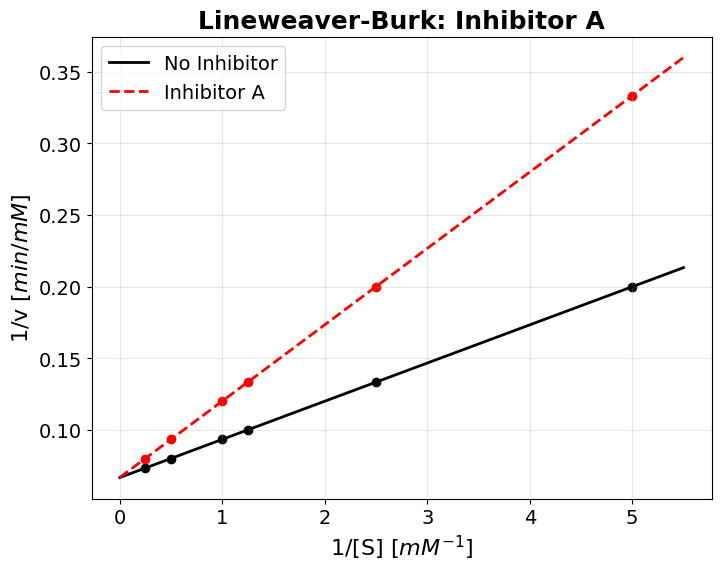

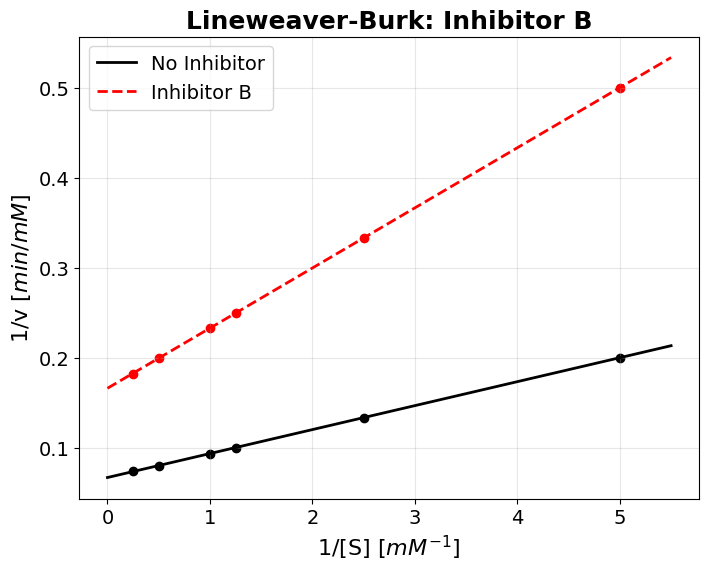

Slope (No Inhibitor): 0.0266 min
Slope (Inhibitor A):  0.0533 min
Slope (Inhibitor B):  0.0668 min


In [3]:

# Data
s_conc = np.array([0.2, 0.4, 0.8, 1.0, 2.0, 4.0])
v_none = np.array([5.0, 7.5, 10.0, 10.7, 12.5, 13.6])
v_a = np.array([3.0, 5.0, 7.5, 8.3, 10.7, 12.5])
v_b = np.array([2.0, 3.0, 4.0, 4.3, 5.0, 5.5])

# Reciprocals -> Setting up the Lineweaver-Burk format
x = 1 / s_conc
y_none = 1 / v_none
y_a = 1 / v_a
y_b = 1 / v_b

def plot_lb(y, name, title):
    plt.figure(figsize=(8, 6))
    plt.rcParams.update({'font.size': 14})
    
    # linear regression
    m1, b1 = np.polyfit(x, y_none, 1)
    m2, b2 = np.polyfit(x, y, 1)
    
    x_range = np.linspace(0, 5.5, 100)
    plt.plot(x_range, m1*x_range + b1, 'k-', label='No Inhibitor', lw=2)
    plt.plot(x_range, m2*x_range + b2, 'r--', label=name, lw=2)
    plt.scatter(x, y_none, color='black')
    plt.scatter(x, y, color='red')

    plt.xlabel('1/[S] [$mM^{-1}$]', fontsize=16)
    plt.ylabel('1/v [$min/mM$]', fontsize=16)
    plt.title(title, fontsize=18, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(f'Images/Exercise_1_{name}.png', dpi=300)
    plt.show()
    
    # Returning both slopes so we can compare them
    return m1, m2

# run plots and grab slopes
slope_none, slope_a = plot_lb(y_a, "Inhibitor A", "Lineweaver-Burk: Inhibitor A")
_, slope_b = plot_lb(y_b, "Inhibitor B", "Lineweaver-Burk: Inhibitor B")

print(f"Slope (No Inhibitor): {slope_none:.4f} min")
print(f"Slope (Inhibitor A):  {slope_a:.4f} min")
print(f"Slope (Inhibitor B):  {slope_b:.4f} min")

- b 

Determining $K_m$ and $V_{max}$ values from the Lineweaver-Burk plot.

In [4]:
def calculate_kinetics(x_recip, y_recip):
    # Linear fit: 1/v = (Km/Vmax) * (1/[S]) + (1/Vmax)
    slope, intercept = np.polyfit(x_recip, y_recip, 1)
    
    v_max = 1 / intercept
    k_m = slope * v_max
    
    return v_max, k_m

vmax_0, km_0 = calculate_kinetics(x, y_none)
vmax_a, km_a = calculate_kinetics(x, y_a)
vmax_b, km_b = calculate_kinetics(x, y_b)

print(f"No Inhibitor: Vmax = {vmax_0:.2f} mM/min, Km = {km_0:.2f} mM")
print(f"Inhibitor A: Vmax = {vmax_a:.2f} mM/min, Km = {km_a:.2f} mM")
print(f"Inhibitor B: Vmax = {vmax_b:.2f} mM/min, Km = {km_b:.2f} mM")

No Inhibitor: Vmax = 14.98 mM/min, Km = 0.40 mM
Inhibitor A: Vmax = 14.96 mM/min, Km = 0.80 mM
Inhibitor B: Vmax = 6.03 mM/min, Km = 0.40 mM


- d

Plotting the data of Inhibitor I at different concentrations in the Lineweaver-Burk format.

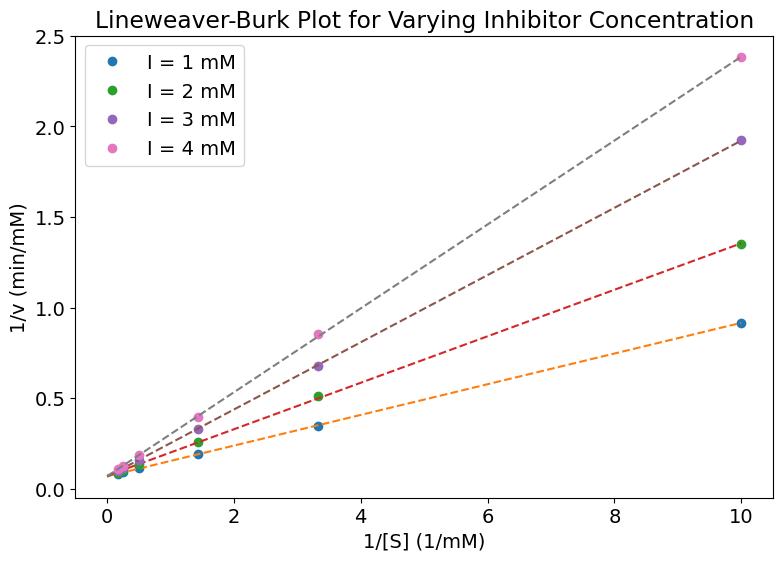

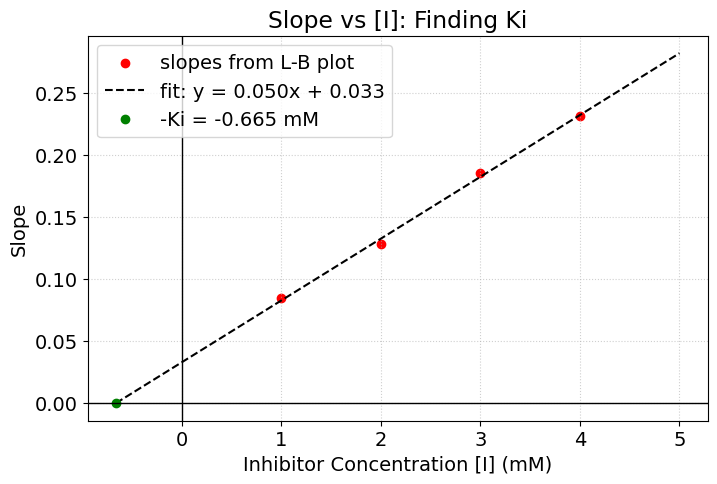

Ki = 0.665 mM


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Data ---
s = np.array([0.1, 0.3, 0.7, 2.0, 4.0, 6.0])
in_conc = [1, 2, 3, 4]  # mM
v = {1: [1.09, 2.89, 5.24, 8.85, 10.89, 12.11], 2: [0.74, 1.96, 3.89, 7.40, 9.82, 11.36], 3: [0.52, 1.47, 3.01, 6.31, 8.76, 10.02], 4: [0.42, 1.17, 2.51, 5.43, 8.07,  9.37]}

inv_s = 1 / s

# Lineweaver-Burk Plot
m_list, b_list = [], []
plt.figure(figsize=(9, 6))
for i in in_conc:
    inv_v = 1 / np.array(v[i])
    m, b = np.polyfit(inv_s, inv_v, 1)
    m_list.append(m)
    b_list.append(b)

    plt.plot(inv_s, inv_v, 'o', label=f'I = {i} mM')
    x_fit = np.array([0, 10])
    plt.plot(x_fit, m*x_fit + b, '--')

plt.xlabel('1/[S] (1/mM)')
plt.ylabel('1/v (min/mM)')
plt.title('Lineweaver-Burk Plot for Varying Inhibitor Concentration')
plt.legend()
plt.savefig('Images/Exercise_1_Inhibitor_I.png', dpi=300)
plt.show()

# Slope vs [I] to find KI
m2, b2 = np.polyfit(in_conc, m_list, 1)
x_intercept = -b2 / m2

x_fit2 = np.linspace(x_intercept, max(in_conc) + 1, 100)

plt.figure(figsize=(8, 5))
plt.scatter(in_conc, m_list, color='red', label='slopes from L-B plot')
plt.plot(x_fit2, m2*x_fit2 + b2, 'k--', label=f'fit: y = {m2:.3f}x + {b2:.3f}')
plt.plot(x_intercept, 0, 'go', label=f'-Ki = {x_intercept:.3f} mM')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Inhibitor Concentration [I] (mM)')
plt.ylabel('Slope')
plt.title('Slope vs [I]: Finding Ki')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('Images/Exercise_1_K_I_plot.png', dpi=300)
plt.show()

print(f"Ki = {abs(x_intercept):.3f} mM")